# Stage 2: Tracking Pipeline

Demonstrates Kalman filter tracking and Hungarian algorithm data association:
1. Track lifecycle management
2. Handling occlusions


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
sys.path.append('..')

from detector import ObjectDetector
from tracker import ObjectTracker, Track

plt.rcParams['figure.figsize'] = (15, 10)


## Setup: Load and Detect

First, detect objects in frames.


In [5]:
frame_pattern = "../data/images/bees_short/images/*.jpg"
frame_files = sorted(glob.glob(frame_pattern))[:100]
frames = [cv2.imread(f) for f in frame_files]

detector = ObjectDetector(history=500, dist_threshold=800, min_area=30, max_area=100000)

# Get detections
all_detections = []
for frame in frames:
    dets = detector.detect(frame)
    all_detections.append(dets)

print(f"Loaded {len(frames)} frames")
print(f"Average detections: {np.mean([len(d) for d in all_detections]):.2f}")


Loaded 100 frames
Average detections: 115.61


## Full Tracking Pipeline


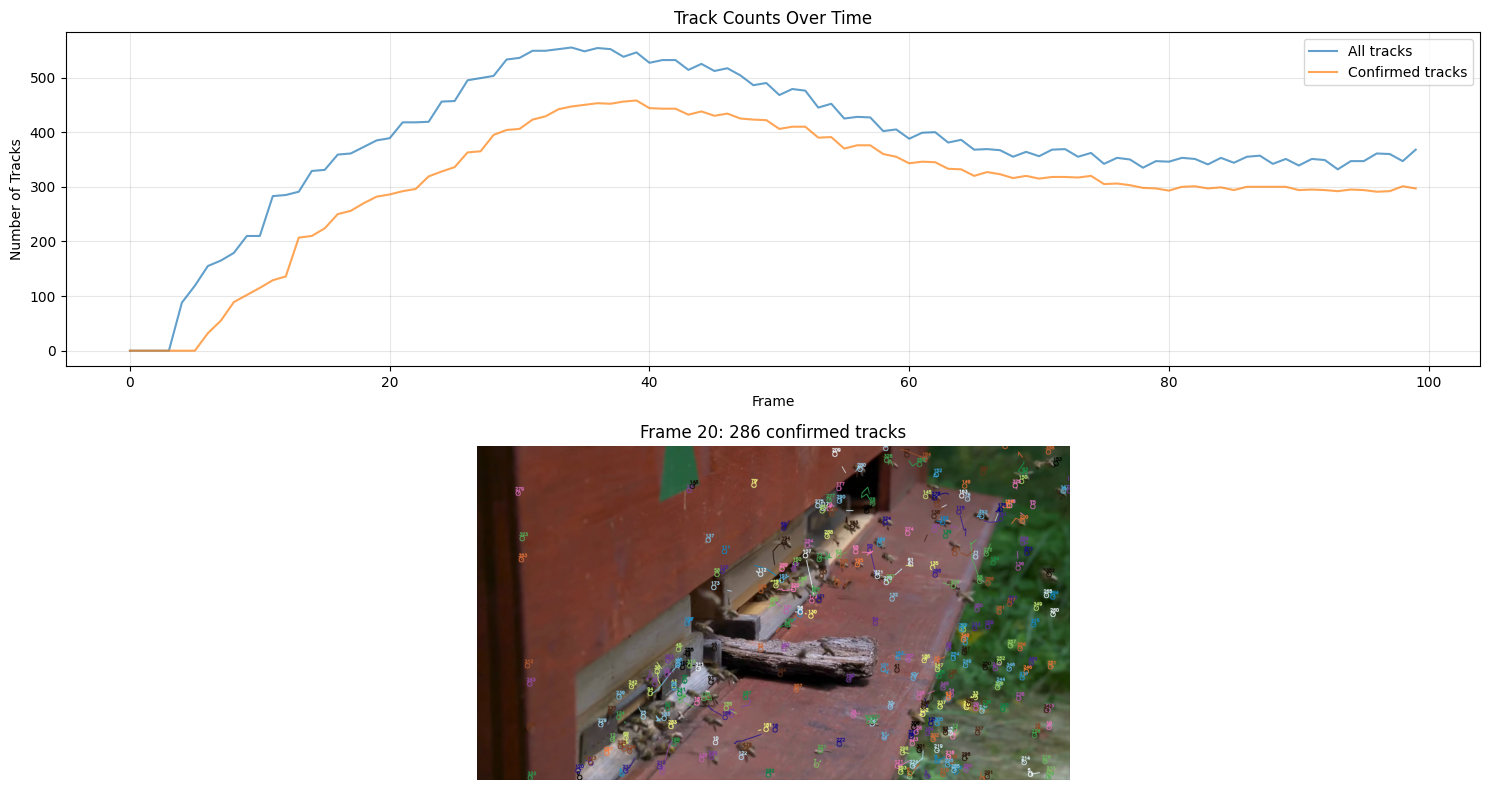

Max tracks: 555
Max confirmed: 458


In [ ]:
tracker = ObjectTracker(max_distance=30.0, min_hits=3, max_age=30)

track_counts = []
confirmed_counts = []

for detections in all_detections:
    tracks = tracker.update(detections)
    confirmed = tracker.get_confirmed_tracks()
    track_counts.append(len(tracks))
    confirmed_counts.append(len(confirmed))

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(track_counts, label='All tracks', alpha=0.7)
axes[0].plot(confirmed_counts, label='Confirmed tracks', alpha=0.7)
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Number of Tracks')
axes[0].set_title('Track Counts Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

test_frames = [20, 40, 60, 80]
tracker.reset()
for i, detections in enumerate(all_detections):
    tracks = tracker.update(detections)
    confirmed = tracker.get_confirmed_tracks()
    
    if i in test_frames:
        idx = test_frames.index(i)
        vis = frames[i].copy()
        
        for track in confirmed:
            cx, cy = int(track.prediction[0]), int(track.prediction[1])
            color = ((track.id * 50) % 255, (track.id * 100) % 255, (track.id * 200) % 255)
            
            cv2.circle(vis, (cx, cy), 8, color, 2)
            cv2.putText(vis, str(track.id), (cx-10, cy-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            if len(track.history) > 1:
                pts = np.array(track.history, np.int32).reshape((-1, 1, 2))
                cv2.polylines(vis, [pts], False, color, 2)
        
        if i == test_frames[0]:
            axes[1].clear()
            axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            axes[1].set_title(f'Frame {i}: {len(confirmed)} confirmed tracks')
            axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Max tracks: {max(track_counts)}")
print(f"Max confirmed: {max(confirmed_counts)}")
